# Adventure Works – Data Loading and Initial Validation

## Module 1: Data Loading & Initial Data Validation

This notebook documents the initial extraction and validation of the datasets provided for the Adventure Works retail sales analytics project.

The purpose of this stage is to understand the structure and initial quality of the source data before performing data cleaning and transformation.

In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
dim_file = "./DimTables.xlsx"
internet_file = "./FactInternetSales.xlsx"
reseller_file = "./FactResellerSales.xlsx"

In [4]:
dim_excel = pd.ExcelFile(dim_file)
internet_excel = pd.ExcelFile(internet_file)
reseller_excel = pd.ExcelFile(reseller_file)

print("DimTables sheets:")
print(dim_excel.sheet_names)

print("\nFactInternetSales sheets:")
print(internet_excel.sheet_names)

print("\nFactResellerSales sheets:")
print(reseller_excel.sheet_names)

DimTables sheets:
['DimCustomer', 'DimEmployee', 'DimGeography', 'DimProduct', 'DimReseller', 'DimSalesTerritory']

FactInternetSales sheets:
['FactInternetSales']

FactResellerSales sheets:
['FactResellerSales']


In [5]:
dim_customer = pd.read_excel(dim_file, sheet_name="DimCustomer")
dim_employee = pd.read_excel(dim_file, sheet_name="DimEmployee")
dim_geography = pd.read_excel(dim_file, sheet_name="DimGeography")
dim_product = pd.read_excel(dim_file, sheet_name="DimProduct")
dim_reseller = pd.read_excel(dim_file, sheet_name="DimReseller")
dim_sales_territory = pd.read_excel(
    dim_file,
    sheet_name="DimSalesTerritory"
)

In [6]:
fact_internet_sales = pd.read_excel(
    internet_file,
    sheet_name="FactInternetSales"
)

fact_reseller_sales = pd.read_excel(
    reseller_file,
    sheet_name="FactResellerSales"
)

In [7]:
datasets = {
    "DimCustomer": dim_customer,
    "DimEmployee": dim_employee,
    "DimGeography": dim_geography,
    "DimProduct": dim_product,
    "DimReseller": dim_reseller,
    "DimSalesTerritory": dim_sales_territory,
    "FactInternetSales": fact_internet_sales,
    "FactResellerSales": fact_reseller_sales
}

In [8]:
dataset_summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

dataset_summary

,Dataset,Rows,Columns
0,DimCustomer,18484,13
1,DimEmployee,21,9
2,DimGeography,655,6
3,DimProduct,397,7
4,DimReseller,701,4
5,DimSalesTerritory,11,4
6,FactInternetSales,60398,13
7,FactResellerSales,60899,14


In [9]:
for name, df in datasets.items():
    print(f"\n{'='*70}")
    print(name)
    print(f"{'='*70}")
    display(df.head(3))


DimCustomer


,CustomerKey,GeographyKey,CustomerName,BirthDate,MaritalStatus,Gender,EmailAddress,YearlyIncome,Education,Occupation,HouseOwnerFlag,Address,FirstPurchaseDate
0,11000,26,Jon Yang,1971-10-06,M,M,jon24@adventure-works.com,90000,Bachelors,Professional,1,3761 N. 14th St,2011-01-19
1,11001,37,Eugene Huang,1976-05-10,S,M,eugene10@adventure-works.com,60000,Bachelors,Professional,0,2243 W St.,2011-01-15
2,11002,31,Ruben Torres,1971-02-09,M,M,ruben35@adventure-works.com,60000,Bachelors,Professional,1,5844 Linden Land,2011-01-07



DimEmployee


,EmployeeKey,ParentEmployeeKey,SalesTerritoryKey,EmployeeName,Title,EmailAddress,DepartmentName,HireDate,BirthDate
0,112,NaN,11,Ken Sánchez,Chief Executive Officer,ken0@adventure-works.com,Executive,2008-08-14,1968-08-29
1,144,112.0,11,Laura Norman,Chief Financial Officer,laura1@adventure-works.com,Executive,2008-08-31,1975-08-06
2,272,277.0,11,Stephen Jiang,North American Sales Manager,stephen0@adventure-works.com,Sales,2010-08-04,1951-05-17



DimGeography


...

,SalesTerritoryKey,SalesTerritoryRegion,SalesTerritoryCountry,SalesTerritoryGroup
0,1,Northwest,United States,North America
1,2,Northeast,United States,North America
2,3,Central,United States,North America



FactInternetSales


,ProductKey,CustomerKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,DiscountAmount,TotalProductCost,SalesAmount,Freight,CarrierTrackingNumber,OrderDate,DueDate,ShipDate
0,310,21768,6,SO43697,1,0,2171.2942,3578.27,89.4568,NaN,2010-12-29,2011-01-10,2011-01-05
1,346,28389,7,SO43698,1,0,1912.1544,3399.99,84.9998,NaN,2010-12-29,2011-01-10,2011-01-05
2,346,25863,1,SO43699,1,0,1912.1544,3399.99,84.9998,NaN,2010-12-29,2011-01-10,2011-01-05



FactResellerSales


,ProductKey,ResellerKey,EmployeeKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,DiscountAmount,TotalProductCost,SalesAmount,Freight,CarrierTrackingNumber,OrderDate,DueDate,ShipDate
0,349.0,676.0,285.0,5.0,SO43659,1.0,0.0,1898.0944,2024.994,50.6249,4911-403C-98,2010-12-29,2011-01-10,2011-01-05
1,350.0,676.0,285.0,5.0,SO43659,2.0,0.0,5694.2832,6074.982,151.8746,4911-403C-98,2010-12-29,2011-01-10,2011-01-05
2,351.0,676.0,285.0,5.0,SO43659,3.0,0.0,1898.0944,2024.994,50.6249,4911-403C-98,2010-12-29,2011-01-10,2011-01-05


In [10]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(list(df.columns))


DimCustomer
['CustomerKey', 'GeographyKey', 'CustomerName', 'BirthDate', 'MaritalStatus', 'Gender', 'EmailAddress', 'YearlyIncome', 'Education', 'Occupation', 'HouseOwnerFlag', 'Address', 'FirstPurchaseDate']

DimEmployee
['EmployeeKey', 'ParentEmployeeKey', 'SalesTerritoryKey', 'EmployeeName', 'Title', 'EmailAddress', 'DepartmentName', 'HireDate', 'BirthDate']

DimGeography
['GeographyKey', 'City', 'State', 'Country', 'PostalCode', 'SalesTerritoryKey']

DimProduct
['ProductKey', 'ProductSubcategoryKey', 'Product', 'Color', 'Model', 'Subcategory', 'Category']

DimReseller
['ResellerKey', 'GeographyKey', 'BusinessType', 'ResellerName']

DimSalesTerritory
['SalesTerritoryKey', 'SalesTerritoryRegion', 'SalesTerritoryCountry', 'SalesTerritoryGroup']

FactInternetSales
['ProductKey', 'CustomerKey', 'SalesTerritoryKey', 'SalesOrderNumber', 'SalesOrderLineNumber', 'DiscountAmount', 'TotalProductCost', 'SalesAmount', 'Freight', 'CarrierTrackingNumber', 'OrderDate', 'DueDate', 'ShipDate']

Fac

In [11]:
for name, df in datasets.items():
    print(f"\n{'='*70}")
    print(name)
    print(f"{'='*70}")
    df.info()


DimCustomer
<class 'pandas.DataFrame'>
RangeIndex: 18484 entries, 0 to 18483
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CustomerKey        18484 non-null  int64         
 1   GeographyKey       18484 non-null  int64         
 2   CustomerName       18484 non-null  str           
 3   BirthDate          18484 non-null  datetime64[us]
 4   MaritalStatus      18484 non-null  str           
 5   Gender             18484 non-null  str           
 6   EmailAddress       18484 non-null  str           
 7   YearlyIncome       18484 non-null  int64         
 8   Education          18484 non-null  str           
 9   Occupation         18484 non-null  str           
 10  HouseOwnerFlag     18484 non-null  int64         
 11  Address            18484 non-null  str           
 12  FirstPurchaseDate  18484 non-null  datetime64[us]
dtypes: datetime64[us](2), int64(4), str(7)
memory usage: 1.8 MB

In [12]:
missing_summary = []

for name, df in datasets.items():
    missing_count = df.isna().sum().sum()
    missing_summary.append({
        "Dataset": name,
        "Missing_Values": missing_count
    })

missing_summary = pd.DataFrame(missing_summary)

missing_summary

,Dataset,Missing_Values
0,DimCustomer,0
1,DimEmployee,1
2,DimGeography,0
3,DimProduct,56
4,DimReseller,0
5,DimSalesTerritory,3
6,FactInternetSales,60398
7,FactResellerSales,534


In [13]:
# Missing Valuse by Colns
for name, df in datasets.items():
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    
    if len(missing) > 0:
        print(f"\n{name}")
        display(missing.to_frame("Missing_Values"))


DimEmployee


,Missing_Values
ParentEmployeeKey,1



DimProduct


,Missing_Values
Color,56



DimSalesTerritory


,Missing_Values
SalesTerritoryRegion,1
SalesTerritoryCountry,1
SalesTerritoryGroup,1



FactInternetSales


,Missing_Values
CarrierTrackingNumber,60398



FactResellerSales


,Missing_Values
ProductKey,44
ResellerKey,44
EmployeeKey,44
SalesTerritoryKey,44
SalesOrderNumber,44
SalesOrderLineNumber,44
DiscountAmount,44
Freight,44
OrderDate,44
CarrierTrackingNumber,44


In [14]:
duplicate_summary = []

for name, df in datasets.items():
    duplicate_summary.append({
        "Dataset": name,
        "Duplicate_Rows": df.duplicated().sum()
    })

duplicate_summary = pd.DataFrame(duplicate_summary)

duplicate_summary

,Dataset,Duplicate_Rows
0,DimCustomer,0
1,DimEmployee,0
2,DimGeography,0
3,DimProduct,0
4,DimReseller,0
5,DimSalesTerritory,0
6,FactInternetSales,0
7,FactResellerSales,2


In [15]:
# Primary Key Validation
key_columns = {
    "DimCustomer": "CustomerKey",
    "DimEmployee": "EmployeeKey",
    "DimGeography": "GeographyKey",
    "DimProduct": "ProductKey",
    "DimReseller": "ResellerKey",
    "DimSalesTerritory": "SalesTerritoryKey"
}

key_validation = []

for dataset_name, key_column in key_columns.items():
    df = datasets[dataset_name]
    
    key_validation.append({
        "Dataset": dataset_name,
        "Key": key_column,
        "Total_Rows": len(df),
        "Unique_Keys": df[key_column].nunique(),
        "Null_Keys": df[key_column].isna().sum(),
        "Duplicate_Keys": df[key_column].duplicated().sum()
    })

key_validation = pd.DataFrame(key_validation)

key_validation

,Dataset,Key,Total_Rows,Unique_Keys,Null_Keys,Duplicate_Keys
0,DimCustomer,CustomerKey,18484,18484,0,0
1,DimEmployee,EmployeeKey,21,21,0,0
2,DimGeography,GeographyKey,655,655,0,0
3,DimProduct,ProductKey,397,397,0,0
4,DimReseller,ResellerKey,701,701,0,0
5,DimSalesTerritory,SalesTerritoryKey,11,11,0,0


In [17]:
# fact-table key inspection
for name in ["FactInternetSales", "FactResellerSales"]:
    df = datasets[name].copy()
    
    duplicate_transactions = df.duplicated(
        subset=["SalesOrderNumber", "SalesOrderLineNumber"]
    ).sum()
    
    print(f"{name}")
    print(
        "Duplicate SalesOrderNumber + SalesOrderLineNumber:",
        duplicate_transactions
    )
    print()

FactInternetSales
Duplicate SalesOrderNumber + SalesOrderLineNumber: 0

FactResellerSales
Duplicate SalesOrderNumber + SalesOrderLineNumber: 43



In [18]:
# Date inspection
date_columns = ["OrderDate", "DueDate", "ShipDate"]

for name in ["FactInternetSales", "FactResellerSales"]:
    df = datasets[name]
    
    print(f"\n{name}")
    
    for column in date_columns:
        print(
            column,
            "| dtype:", df[column].dtype,
            "| min:", df[column].min(),
            "| max:", df[column].max(),
            "| nulls:", df[column].isna().sum()
        )


FactInternetSales
OrderDate | dtype: str | min: 2010-12-29 | max: 2014-01-28 | nulls: 0
DueDate | dtype: str | min: 2011-01-10 | max: 2014-02-09 | nulls: 0
ShipDate | dtype: str | min: 2011-01-05 | max: 2014-02-04 | nulls: 0

FactResellerSales
OrderDate | dtype: str | min: 2010-12-29 | max: 2013-11-29 | nulls: 44
DueDate | dtype: str | min: 2011-01-10 | max: 2013-12-11 | nulls: 44
ShipDate | dtype: str | min: 2011-01-05 | max: 2013-12-06 | nulls: 44


In [19]:
#  Investigating 44 Problamatic rows
reseller_missing_keys = fact_reseller_sales[
    fact_reseller_sales["ProductKey"].isna()
]

print("Rows with missing ProductKey:", len(reseller_missing_keys))

display(reseller_missing_keys)

Rows with missing ProductKey: 44


,ProductKey,ResellerKey,EmployeeKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,DiscountAmount,TotalProductCost,SalesAmount,Freight,CarrierTrackingNumber,OrderDate,DueDate,ShipDate
352,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.722951e+05,4.893286e+05,NaN,NaN,NaN,NaN,NaN
353,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1139,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.469460e+06,1.538408e+06,NaN,NaN,NaN,NaN,NaN
1733,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.108483e+06,1.165897e+06,NaN,NaN,NaN,NaN,NaN
2233,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.171295e+05,8.447210e+05,NaN,NaN,NaN,NaN,NaN
3340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.236063e+06,2.324136e+06,NaN,NaN,NaN,NaN,NaN
4144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.633078e+06,1.702945e+06,NaN,NaN,NaN,NaN,NaN
4522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.904294e+05,7.131167e+05,NaN,NaN,NaN,NaN,NaN
5389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.830481e+06,1.900789e+06,NaN,NaN,NaN,NaN,NaN
6043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.396767e+06,1.455280e+06,NaN,NaN,NaN,NaN,NaN


In [20]:
reseller_missing_keys.isna().sum()

ProductKey               44
ResellerKey              44
EmployeeKey              44
SalesTerritoryKey        44
SalesOrderNumber         44
SalesOrderLineNumber     44
DiscountAmount           44
TotalProductCost          3
SalesAmount               3
Freight                  44
CarrierTrackingNumber    44
OrderDate                44
DueDate                  44
ShipDate                 44
dtype: int64

In [21]:
reseller_missing_keys.shape

(44, 14)

In [22]:
display(
    reseller_missing_keys[
        ["ProductKey",
         "ResellerKey",
         "EmployeeKey",
         "SalesTerritoryKey",
         "SalesOrderNumber",
         "SalesOrderLineNumber",
         "SalesAmount",
         "TotalProductCost",
         "OrderDate",
         "DueDate",
         "ShipDate"]
    ]
)

,ProductKey,ResellerKey,EmployeeKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,SalesAmount,TotalProductCost,OrderDate,DueDate,ShipDate
352,NaN,NaN,NaN,NaN,NaN,NaN,4.893286e+05,4.722951e+05,NaN,NaN,NaN
353,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1139,NaN,NaN,NaN,NaN,NaN,NaN,1.538408e+06,1.469460e+06,NaN,NaN,NaN
1733,NaN,NaN,NaN,NaN,NaN,NaN,1.165897e+06,1.108483e+06,NaN,NaN,NaN
2233,NaN,NaN,NaN,NaN,NaN,NaN,8.447210e+05,8.171295e+05,NaN,NaN,NaN
3340,NaN,NaN,NaN,NaN,NaN,NaN,2.324136e+06,2.236063e+06,NaN,NaN,NaN
4144,NaN,NaN,NaN,NaN,NaN,NaN,1.702945e+06,1.633078e+06,NaN,NaN,NaN
4522,NaN,NaN,NaN,NaN,NaN,NaN,7.131167e+05,6.904294e+05,NaN,NaN,NaN
5389,NaN,NaN,NaN,NaN,NaN,NaN,1.900789e+06,1.830481e+06,NaN,NaN,NaN
6043,NaN,NaN,NaN,NaN,NaN,NaN,1.455280e+06,1.396767e+06,NaN,NaN,NaN


In [23]:
duplicate_transaction_rows = fact_reseller_sales[
    fact_reseller_sales.duplicated(
        subset=["SalesOrderNumber", "SalesOrderLineNumber"],
        keep=False
    )
].sort_values(
    ["SalesOrderNumber", "SalesOrderLineNumber"]
)

print("Rows involved in duplicate transaction keys:",
      len(duplicate_transaction_rows))

display(duplicate_transaction_rows)

Rows involved in duplicate transaction keys: 44


,ProductKey,ResellerKey,EmployeeKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,DiscountAmount,TotalProductCost,SalesAmount,Freight,CarrierTrackingNumber,OrderDate,DueDate,ShipDate
352,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.722951e+05,4.893286e+05,NaN,NaN,NaN,NaN,NaN
353,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1139,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.469460e+06,1.538408e+06,NaN,NaN,NaN,NaN,NaN
1733,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.108483e+06,1.165897e+06,NaN,NaN,NaN,NaN,NaN
2233,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.171295e+05,8.447210e+05,NaN,NaN,NaN,NaN,NaN
3340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.236063e+06,2.324136e+06,NaN,NaN,NaN,NaN,NaN
4144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.633078e+06,1.702945e+06,NaN,NaN,NaN,NaN,NaN
4522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.904294e+05,7.131167e+05,NaN,NaN,NaN,NaN,NaN
5389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.830481e+06,1.900789e+06,NaN,NaN,NaN,NaN,NaN
6043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.396767e+06,1.455280e+06,NaN,NaN,NaN,NaN,NaN


In [24]:
print(
    "Duplicate transaction rows with missing ProductKey:",
    duplicate_transaction_rows["ProductKey"].isna().sum()
)

Duplicate transaction rows with missing ProductKey: 44


In [25]:
exact_duplicates = fact_reseller_sales[
    fact_reseller_sales.duplicated(keep=False)
].sort_values(
    ["SalesOrderNumber", "SalesOrderLineNumber"]
)

print("Rows involved in exact duplicate records:",
      len(exact_duplicates))

display(exact_duplicates)

Rows involved in exact duplicate records: 3


,ProductKey,ResellerKey,EmployeeKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,DiscountAmount,TotalProductCost,SalesAmount,Freight,CarrierTrackingNumber,OrderDate,DueDate,ShipDate
353,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10196,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32342,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# Count rows with a valid SalesOrderNumber
valid_order_numbers = fact_reseller_sales["SalesOrderNumber"].notna()

print("Rows with SalesOrderNumber:", valid_order_numbers.sum())
print("Rows without SalesOrderNumber:", (~valid_order_numbers).sum())

Rows with SalesOrderNumber: 60855
Rows without SalesOrderNumber: 44


In [27]:
# Duplicate transaction keys among rows that actually have an order number
valid_reseller_sales = fact_reseller_sales[
    fact_reseller_sales["SalesOrderNumber"].notna()
].copy()

duplicate_valid_transactions = valid_reseller_sales.duplicated(
    subset=["SalesOrderNumber", "SalesOrderLineNumber"],
    keep=False
)

print(
    "Rows involved in duplicate transaction keys among valid orders:",
    duplicate_valid_transactions.sum()
)

Rows involved in duplicate transaction keys among valid orders: 0


In [28]:
display(
    valid_reseller_sales[
        duplicate_valid_transactions
    ].sort_values(
        ["SalesOrderNumber", "SalesOrderLineNumber"]
    )
)

,ProductKey,ResellerKey,EmployeeKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,DiscountAmount,TotalProductCost,SalesAmount,Freight,CarrierTrackingNumber,OrderDate,DueDate,ShipDate


In [29]:
# Financial rows
financially_populated_missing_rows = fact_reseller_sales[
    fact_reseller_sales["SalesOrderNumber"].isna()
    & (
        fact_reseller_sales["SalesAmount"].notna()
        | fact_reseller_sales["TotalProductCost"].notna()
    )
]

print(
    "Rows without SalesOrderNumber but with financial values:",
    len(financially_populated_missing_rows)
)

display(financially_populated_missing_rows)

Rows without SalesOrderNumber but with financial values: 41


,ProductKey,ResellerKey,EmployeeKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,DiscountAmount,TotalProductCost,SalesAmount,Freight,CarrierTrackingNumber,OrderDate,DueDate,ShipDate
352,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.722951e+05,4.893286e+05,NaN,NaN,NaN,NaN,NaN
1139,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.469460e+06,1.538408e+06,NaN,NaN,NaN,NaN,NaN
1733,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.108483e+06,1.165897e+06,NaN,NaN,NaN,NaN,NaN
2233,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.171295e+05,8.447210e+05,NaN,NaN,NaN,NaN,NaN
3340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.236063e+06,2.324136e+06,NaN,NaN,NaN,NaN,NaN
4144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.633078e+06,1.702945e+06,NaN,NaN,NaN,NaN,NaN
4522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.904294e+05,7.131167e+05,NaN,NaN,NaN,NaN,NaN
5389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.830481e+06,1.900789e+06,NaN,NaN,NaN,NaN,NaN
6043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.396767e+06,1.455280e+06,NaN,NaN,NaN,NaN,NaN
6538,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.546459e+05,8.828999e+05,NaN,NaN,NaN,NaN,NaN


In [30]:
for index, row in financially_populated_missing_rows.iterrows():
    
    matches = fact_reseller_sales[
        (fact_reseller_sales["SalesAmount"] == row["SalesAmount"]) &
        (fact_reseller_sales["TotalProductCost"] == row["TotalProductCost"])
    ]
    
    print(f"\nOriginal row index: {index}")
    print("Matching rows based on SalesAmount + TotalProductCost:")
    display(matches)


Original row index: 352
Matching rows based on SalesAmount + TotalProductCost:


,ProductKey,ResellerKey,EmployeeKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,DiscountAmount,TotalProductCost,SalesAmount,Freight,CarrierTrackingNumber,OrderDate,DueDate,ShipDate
352,NaN,NaN,NaN,NaN,NaN,NaN,NaN,472295.1427,489328.5787,NaN,NaN,NaN,NaN,NaN



Original row index: 1139
Matching rows based on SalesAmount + TotalProductCost:


,ProductKey,ResellerKey,EmployeeKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,DiscountAmount,TotalProductCost,SalesAmount,Freight,CarrierTrackingNumber,OrderDate,DueDate,ShipDate
1139,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.469460e+06,1.538408e+06,NaN,NaN,NaN,NaN,NaN



Original row index: 1733
Matching rows based on SalesAmount + TotalProductCost:


...

,ProductKey,ResellerKey,EmployeeKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,DiscountAmount,TotalProductCost,SalesAmount,Freight,CarrierTrackingNumber,OrderDate,DueDate,ShipDate
57894,NaN,NaN,NaN,NaN,NaN,NaN,NaN,748.0582,755.784,NaN,NaN,NaN,NaN,NaN



Original row index: 60897
Matching rows based on SalesAmount + TotalProductCost:


,ProductKey,ResellerKey,EmployeeKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,DiscountAmount,TotalProductCost,SalesAmount,Freight,CarrierTrackingNumber,OrderDate,DueDate,ShipDate
60897,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.430306e+06,3415479.07,NaN,NaN,NaN,NaN,NaN



Original row index: 60898
Matching rows based on SalesAmount + TotalProductCost:


,ProductKey,ResellerKey,EmployeeKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,DiscountAmount,TotalProductCost,SalesAmount,Freight,CarrierTrackingNumber,OrderDate,DueDate,ShipDate
60898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.998011e+07,8.045060e+07,NaN,NaN,NaN,NaN,NaN


In [31]:
# Verify the 44 incomplete reseller rows
incomplete_reseller = fact_reseller_sales[
    fact_reseller_sales["SalesOrderNumber"].isna()
].copy()

print("Rows without SalesOrderNumber:", len(incomplete_reseller))

print(
    "\nRows with SalesOrderNumber missing AND SalesAmount present:",
    incomplete_reseller["SalesAmount"].notna().sum()
)

print(
    "Rows with SalesOrderNumber missing AND TotalProductCost present:",
    incomplete_reseller["TotalProductCost"].notna().sum()
)

print(
    "Rows with SalesOrderNumber missing AND both financial fields present:",
    (
        incomplete_reseller["SalesAmount"].notna()
        & incomplete_reseller["TotalProductCost"].notna()
    ).sum()
)

Rows without SalesOrderNumber: 44

Rows with SalesOrderNumber missing AND SalesAmount present: 41
Rows with SalesOrderNumber missing AND TotalProductCost present: 41
Rows with SalesOrderNumber missing AND both financial fields present: 41


In [32]:
incomplete_reseller[
    ["SalesAmount", "TotalProductCost"]
].notna().sum()

SalesAmount         41
TotalProductCost    41
dtype: int64

In [33]:
exact_duplicate_count = fact_reseller_sales.duplicated().sum()

exact_duplicate_rows = fact_reseller_sales[
    fact_reseller_sales.duplicated(keep=False)
]

print("Duplicate occurrences:", exact_duplicate_count)
print("Rows participating in duplicate groups:", len(exact_duplicate_rows))

display(exact_duplicate_rows)

Duplicate occurrences: 2
Rows participating in duplicate groups: 3


,ProductKey,ResellerKey,EmployeeKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,DiscountAmount,TotalProductCost,SalesAmount,Freight,CarrierTrackingNumber,OrderDate,DueDate,ShipDate
353,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10196,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32342,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning & Transformation

In [34]:
# Create working copies so the original extracted data remains unchanged

clean_dim_customer = dim_customer.copy()
clean_dim_employee = dim_employee.copy()
clean_dim_geography = dim_geography.copy()
clean_dim_product = dim_product.copy()
clean_dim_reseller = dim_reseller.copy()
clean_dim_sales_territory = dim_sales_territory.copy()

clean_fact_internet_sales = fact_internet_sales.copy()
clean_fact_reseller_sales = fact_reseller_sales.copy()

In [35]:
clean_datasets = {
    "DimCustomer": clean_dim_customer,
    "DimEmployee": clean_dim_employee,
    "DimGeography": clean_dim_geography,
    "DimProduct": clean_dim_product,
    "DimReseller": clean_dim_reseller,
    "DimSalesTerritory": clean_dim_sales_territory,
    "FactInternetSales": clean_fact_internet_sales,
    "FactResellerSales": clean_fact_reseller_sales
}

In [36]:
for name, df in clean_datasets.items():
    print(f"{name}: {df.shape}")

DimCustomer: (18484, 13)
DimEmployee: (21, 9)
DimGeography: (655, 6)
DimProduct: (397, 7)
DimReseller: (701, 4)
DimSalesTerritory: (11, 4)
FactInternetSales: (60398, 13)
FactResellerSales: (60899, 14)


In [37]:
incomplete_reseller = clean_fact_reseller_sales[
    clean_fact_reseller_sales["SalesOrderNumber"].isna()
].copy()

print("Incomplete reseller rows:", len(incomplete_reseller))

print(
    "Total SalesAmount in incomplete rows:",
    incomplete_reseller["SalesAmount"].sum()
)

print(
    "Total Product Cost in incomplete rows:",
    incomplete_reseller["TotalProductCost"].sum()
)

Incomplete reseller rows: 44
Total SalesAmount in incomplete rows: 160901193.964599
Total Product Cost in incomplete rows: 159960228.7579893


In [38]:
print(
    "Total SalesAmount in all reseller rows:",
    clean_fact_reseller_sales["SalesAmount"].sum()
)

print(
    "Total Product Cost in all reseller rows:",
    clean_fact_reseller_sales["TotalProductCost"].sum()
)

Total SalesAmount in all reseller rows: 241351790.94689903
Total Product Cost in all reseller rows: 239940343.13698927


In [39]:
incomplete_sales = incomplete_reseller["SalesAmount"].sum()
total_sales = clean_fact_reseller_sales["SalesAmount"].sum()

incomplete_cost = incomplete_reseller["TotalProductCost"].sum()
total_cost = clean_fact_reseller_sales["TotalProductCost"].sum()

print(
    "Incomplete rows - SalesAmount %:",
    round((incomplete_sales / total_sales) * 100, 4)
)

print(
    "Incomplete rows - TotalProductCost %:",
    round((incomplete_cost / total_cost) * 100, 4)
)

Incomplete rows - SalesAmount %: 66.6667
Incomplete rows - TotalProductCost %: 66.6667


In [40]:
# records have any recoverable identifiers
# IF any
financial_incomplete = incomplete_reseller[
    incomplete_reseller["SalesAmount"].notna()
].copy()

print("Financial incomplete records:", len(financial_incomplete))

display(
    financial_incomplete[
        [
            "ProductKey",
            "ResellerKey",
            "EmployeeKey",
            "SalesTerritoryKey",
            "SalesOrderNumber",
            "SalesOrderLineNumber",
            "SalesAmount",
            "TotalProductCost",
            "Freight",
            "DiscountAmount",
            "OrderDate",
            "DueDate",
            "ShipDate"
        ]
    ].head(10)
)

Financial incomplete records: 41


,ProductKey,ResellerKey,EmployeeKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,SalesAmount,TotalProductCost,Freight,DiscountAmount,OrderDate,DueDate,ShipDate
352,NaN,NaN,NaN,NaN,NaN,NaN,4.893286e+05,4.722951e+05,NaN,NaN,NaN,NaN,NaN
1139,NaN,NaN,NaN,NaN,NaN,NaN,1.538408e+06,1.469460e+06,NaN,NaN,NaN,NaN,NaN
1733,NaN,NaN,NaN,NaN,NaN,NaN,1.165897e+06,1.108483e+06,NaN,NaN,NaN,NaN,NaN
2233,NaN,NaN,NaN,NaN,NaN,NaN,8.447210e+05,8.171295e+05,NaN,NaN,NaN,NaN,NaN
3340,NaN,NaN,NaN,NaN,NaN,NaN,2.324136e+06,2.236063e+06,NaN,NaN,NaN,NaN,NaN
4144,NaN,NaN,NaN,NaN,NaN,NaN,1.702945e+06,1.633078e+06,NaN,NaN,NaN,NaN,NaN
4522,NaN,NaN,NaN,NaN,NaN,NaN,7.131167e+05,6.904294e+05,NaN,NaN,NaN,NaN,NaN
5389,NaN,NaN,NaN,NaN,NaN,NaN,1.900789e+06,1.830481e+06,NaN,NaN,NaN,NaN,NaN
6043,NaN,NaN,NaN,NaN,NaN,NaN,1.455280e+06,1.396767e+06,NaN,NaN,NaN,NaN,NaN
6538,NaN,NaN,NaN,NaN,NaN,NaN,8.828999e+05,8.546459e+05,NaN,NaN,NaN,NaN,NaN


# Further Investigation as above is not sufficient for desigion 

In [41]:
valid_reseller = clean_fact_reseller_sales[
    clean_fact_reseller_sales["SalesOrderNumber"].notna()
].copy()

print("Valid reseller rows:", len(valid_reseller))
print("Incomplete reseller rows:", len(incomplete_reseller))

print("\nValid SalesAmount:")
print(valid_reseller["SalesAmount"].describe())

print("\nIncomplete SalesAmount:")
print(incomplete_reseller["SalesAmount"].describe())

print("\nValid TotalProductCost:")
print(valid_reseller["TotalProductCost"].describe())

print("\nIncomplete TotalProductCost:")
print(incomplete_reseller["TotalProductCost"].describe())

Valid reseller rows: 60855
Incomplete reseller rows: 44

Valid SalesAmount:
count    60855.000000
mean      1322.004716
std       2124.233758
min          1.374000
25%        127.800000
50%        461.694000
75%       1466.010000
max      27893.619000
Name: SalesAmount, dtype: float64

Incomplete SalesAmount:
count    4.100000e+01
mean     3.924419e+06
std      1.230136e+07
min      8.156400e+01
25%      1.317542e+06
50%      2.185213e+06
75%      2.880753e+06
max      8.045060e+07
Name: SalesAmount, dtype: float64

Valid TotalProductCost:
count    60855.000000
mean      1314.273509
std       2159.575059
min          0.856500
25%         96.912200
50%        461.444800
75%       1510.301600
max      38530.385400
Name: TotalProductCost, dtype: float64

Incomplete TotalProductCost:
count    4.100000e+01
mean     3.901469e+06
std      1.223124e+07
min      1.046738e+02
25%      1.396767e+06
50%      2.073508e+06
75%      2.765546e+06
max      7.998011e+07
Name: TotalProductCost, dtype: fl

In [42]:
incomplete_reseller.notna().sum().sort_values(ascending=False)

SalesAmount              41
TotalProductCost         41
EmployeeKey               0
SalesTerritoryKey         0
ProductKey                0
ResellerKey               0
SalesOrderLineNumber      0
SalesOrderNumber          0
DiscountAmount            0
Freight                   0
CarrierTrackingNumber     0
OrderDate                 0
DueDate                   0
ShipDate                  0
dtype: int64

In [43]:
display(
    incomplete_reseller[
        incomplete_reseller.notna().sum(axis=1) > 2
    ]
)

,ProductKey,ResellerKey,EmployeeKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,DiscountAmount,TotalProductCost,SalesAmount,Freight,CarrierTrackingNumber,OrderDate,DueDate,ShipDate


In [44]:
print("Valid SalesAmount total:",
      valid_reseller["SalesAmount"].sum())

print("Incomplete SalesAmount total:",
      incomplete_reseller["SalesAmount"].sum())

print("\nValid row count:", len(valid_reseller))
print("Incomplete row count:", len(incomplete_reseller))

print("\nAverage valid SalesAmount:",
      valid_reseller["SalesAmount"].mean())

print("Average incomplete SalesAmount:",
      incomplete_reseller["SalesAmount"].mean())

Valid SalesAmount total: 80450596.98230001
Incomplete SalesAmount total: 160901193.964599

Valid row count: 60855
Incomplete row count: 44

Average valid SalesAmount: 1322.0047158376472
Average incomplete SalesAmount: 3924419.36499022


# Remove the 44 incomplete rows

In [51]:
# Remove reseller sales records without a SalesOrderNumber

before_count = len(clean_fact_reseller_sales)

clean_fact_reseller_sales = clean_fact_reseller_sales[
    clean_fact_reseller_sales["SalesOrderNumber"].notna()
].copy()

after_count = len(clean_fact_reseller_sales)

print("Rows before cleaning:", before_count)
print("Rows removed:", before_count - after_count)
print("Rows after cleaning:", after_count)

# Validate
print(
    "Missing SalesOrderNumber after cleaning:",
    clean_fact_reseller_sales["SalesOrderNumber"].isna().sum()
)

print(
    "Missing ProductKey after cleaning:",
    clean_fact_reseller_sales["ProductKey"].isna().sum()
)

print(
    "Missing ResellerKey after cleaning:",
    clean_fact_reseller_sales["ResellerKey"].isna().sum()
)

print(
    "Missing EmployeeKey after cleaning:",
    clean_fact_reseller_sales["EmployeeKey"].isna().sum()
)

print(
    "Missing SalesTerritoryKey after cleaning:",
    clean_fact_reseller_sales["SalesTerritoryKey"].isna().sum()
)

Rows before cleaning: 60855
Rows removed: 0
Rows after cleaning: 60855
Missing SalesOrderNumber after cleaning: 0
Missing ProductKey after cleaning: 0
Missing ResellerKey after cleaning: 0
Missing EmployeeKey after cleaning: 0
Missing SalesTerritoryKey after cleaning: 0


In [48]:
# Rechecking transaction duplicates
duplicate_transactions_after_cleaning = (
    clean_fact_reseller_sales.duplicated(
        subset=["SalesOrderNumber", "SalesOrderLineNumber"],
        keep=False
    )
)

print(
    "Rows involved in duplicate transaction keys:",
    duplicate_transactions_after_cleaning.sum()
)

Rows involved in duplicate transaction keys: 0


In [49]:
print(
    "Exact duplicate occurrences after cleaning:",
    clean_fact_reseller_sales.duplicated().sum()
)

Exact duplicate occurrences after cleaning: 0


In [50]:
# cleaned dataset
print("Clean FactResellerSales shape:",
      clean_fact_reseller_sales.shape)

display(clean_fact_reseller_sales.head())

Clean FactResellerSales shape: (60855, 14)


,ProductKey,ResellerKey,EmployeeKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,DiscountAmount,TotalProductCost,SalesAmount,Freight,CarrierTrackingNumber,OrderDate,DueDate,ShipDate
0,349.0,676.0,285.0,5.0,SO43659,1.0,0.0,1898.0944,2024.994,50.6249,4911-403C-98,2010-12-29,2011-01-10,2011-01-05
1,350.0,676.0,285.0,5.0,SO43659,2.0,0.0,5694.2832,6074.982,151.8746,4911-403C-98,2010-12-29,2011-01-10,2011-01-05
2,351.0,676.0,285.0,5.0,SO43659,3.0,0.0,1898.0944,2024.994,50.6249,4911-403C-98,2010-12-29,2011-01-10,2011-01-05
3,344.0,676.0,285.0,5.0,SO43659,4.0,0.0,1912.1544,2039.994,50.9999,4911-403C-98,2010-12-29,2011-01-10,2011-01-05
4,345.0,676.0,285.0,5.0,SO43659,5.0,0.0,1912.1544,2039.994,50.9999,4911-403C-98,2010-12-29,2011-01-10,2011-01-05


In [59]:
print("Raw FactResellerSales shape:",
      fact_reseller_sales.shape)

print(
    "Raw rows without SalesOrderNumber:",
    fact_reseller_sales["SalesOrderNumber"].isna().sum()
)

Raw FactResellerSales shape: (60899, 14)
Raw rows without SalesOrderNumber: 44


In [60]:
print("Clean FactResellerSales shape:",
      clean_fact_reseller_sales.shape)

print(
    "Clean rows without SalesOrderNumber:",
    clean_fact_reseller_sales["SalesOrderNumber"].isna().sum()
)

Clean FactResellerSales shape: (60855, 14)
Clean rows without SalesOrderNumber: 0


In [61]:
raw_index_set = set(fact_reseller_sales.index)
clean_index_set = set(clean_fact_reseller_sales.index)

print(
    "Rows in raw but not in clean:",
    len(raw_index_set - clean_index_set)
)

print(
    "Rows in clean but not in raw:",
    len(clean_index_set - raw_index_set)
)

Rows in raw but not in clean: 44
Rows in clean but not in raw: 0


In [62]:
excluded_rows = fact_reseller_sales.loc[
    ~fact_reseller_sales.index.isin(clean_fact_reseller_sales.index)
].copy()

print("Excluded rows:", len(excluded_rows))

display(excluded_rows.head())

Excluded rows: 44


,ProductKey,ResellerKey,EmployeeKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,DiscountAmount,TotalProductCost,SalesAmount,Freight,CarrierTrackingNumber,OrderDate,DueDate,ShipDate
352,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.722951e+05,4.893286e+05,NaN,NaN,NaN,NaN,NaN
353,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1139,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.469460e+06,1.538408e+06,NaN,NaN,NaN,NaN,NaN
1733,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.108483e+06,1.165897e+06,NaN,NaN,NaN,NaN,NaN
2233,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.171295e+05,8.447210e+05,NaN,NaN,NaN,NaN,NaN


In [63]:
print(
    "Excluded rows with SalesAmount:",
    excluded_rows["SalesAmount"].notna().sum()
)

print(
    "Excluded rows with TotalProductCost:",
    excluded_rows["TotalProductCost"].notna().sum()
)

Excluded rows with SalesAmount: 41
Excluded rows with TotalProductCost: 41


In [64]:
print("FACT RESELLER SALES - CLEANING VALIDATION")
print("-" * 50)

print(f"Raw rows: {len(fact_reseller_sales):,}")
print(
    f"Rows without SalesOrderNumber: "
    f"{fact_reseller_sales['SalesOrderNumber'].isna().sum():,}"
)
print(f"Excluded rows: {len(excluded_rows):,}")
print(f"Clean rows: {len(clean_fact_reseller_sales):,}")

print()

print(
    "Missing SalesOrderNumber after cleaning:",
    clean_fact_reseller_sales["SalesOrderNumber"].isna().sum()
)

print(
    "Duplicate transaction keys after cleaning:",
    clean_fact_reseller_sales.duplicated(
        subset=["SalesOrderNumber", "SalesOrderLineNumber"],
        keep=False
    ).sum()
)

print(
    "Exact duplicate occurrences after cleaning:",
    clean_fact_reseller_sales.duplicated().sum()
)

FACT RESELLER SALES - CLEANING VALIDATION
--------------------------------------------------
Raw rows: 60,899
Rows without SalesOrderNumber: 44
Excluded rows: 44
Clean rows: 60,855

Missing SalesOrderNumber after cleaning: 0
Duplicate transaction keys after cleaning: 0
Exact duplicate occurrences after cleaning: 0


## Compare duplicate counts

In [65]:
print("RAW DATA")
print("-" * 30)

print(
    "Exact duplicate occurrences:",
    fact_reseller_sales.duplicated().sum()
)

print(
    "Rows involved in duplicate groups:",
    fact_reseller_sales.duplicated(keep=False).sum()
)

print("\nCLEAN DATA")
print("-" * 30)

print(
    "Exact duplicate occurrences:",
    clean_fact_reseller_sales.duplicated().sum()
)

print(
    "Rows involved in duplicate groups:",
    clean_fact_reseller_sales.duplicated(keep=False).sum()
)

RAW DATA
------------------------------
Exact duplicate occurrences: 2
Rows involved in duplicate groups: 3

CLEAN DATA
------------------------------
Exact duplicate occurrences: 0
Rows involved in duplicate groups: 0


## Missing Value

In [66]:
# DimProduct
product_missing_color = clean_dim_product[
    clean_dim_product["Color"].isna()
].copy()

print("Products with missing Color:", len(product_missing_color))

display(product_missing_color)

Products with missing Color: 56


,ProductKey,ProductSubcategoryKey,Product,Color,Model,Subcategory,Category
12,391,10,LL Fork,NaN,LL Fork,Forks,Components
13,392,10,ML Fork,NaN,ML Fork,Forks,Components
14,393,10,HL Fork,NaN,HL Fork,Forks,Components
15,397,4,LL Mountain Handlebars,NaN,LL Mountain Handlebars,Handlebars,Components
16,398,4,LL Mountain Handlebars,NaN,LL Mountain Handlebars,Handlebars,Components
26,447,34,Cable Lock,NaN,Cable Lock,Locks,Accessories
27,448,36,Minipump,NaN,Minipump,Pumps,Accessories
28,449,36,Mountain Pump,NaN,Mountain Pump,Pumps,Accessories
29,450,33,Taillights - Battery-Powered,NaN,Taillight,Lights,Accessories
30,451,33,Headlights - Dual-Beam,NaN,Headlights - Dual-Beam,Lights,Accessories


In [67]:
print(clean_dim_product.columns.tolist())

['ProductKey', 'ProductSubcategoryKey', 'Product', 'Color', 'Model', 'Subcategory', 'Category']


In [68]:
display(
    product_missing_color.describe(include="all").T
)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ProductKey,56.0,NaN,NaN,NaN,476.375,63.54399,391.0,404.75,481.5,528.25,603.0
ProductSubcategoryKey,56.0,NaN,NaN,NaN,19.232143,13.379755,4.0,4.75,15.0,33.25,37.0
Product,56,50,LL Mountain Handlebars,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Color,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,56,50,LL Mountain Handlebars,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Subcategory,56,14,Handlebars,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,56,2,Components,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
display(
    product_missing_color.head(20)
)

,ProductKey,ProductSubcategoryKey,Product,Color,Model,Subcategory,Category
12,391,10,LL Fork,NaN,LL Fork,Forks,Components
13,392,10,ML Fork,NaN,ML Fork,Forks,Components
14,393,10,HL Fork,NaN,HL Fork,Forks,Components
15,397,4,LL Mountain Handlebars,NaN,LL Mountain Handlebars,Handlebars,Components
16,398,4,LL Mountain Handlebars,NaN,LL Mountain Handlebars,Handlebars,Components
26,447,34,Cable Lock,NaN,Cable Lock,Locks,Accessories
27,448,36,Minipump,NaN,Minipump,Pumps,Accessories
28,449,36,Mountain Pump,NaN,Mountain Pump,Pumps,Accessories
29,450,33,Taillights - Battery-Powered,NaN,Taillight,Lights,Accessories
30,451,33,Headlights - Dual-Beam,NaN,Headlights - Dual-Beam,Lights,Accessories


In [70]:
print(
    "Missing Color before cleaning:",
    clean_dim_product["Color"].isna().sum()
)

Missing Color before cleaning: 56


In [71]:
print(
    clean_dim_product["Color"].value_counts(dropna=False)
)

Color
Black           129
Red              63
NaN              56
Yellow           46
Silver           45
Blue             28
Multi            18
Silver/Black      7
White             4
Grey              1
Name: count, dtype: int64


In [72]:
clean_dim_product["Color"] = (
    clean_dim_product["Color"].fillna("Unknown")
)

In [73]:
print(
    "Missing Color after cleaning:",
    clean_dim_product["Color"].isna().sum()
)

Missing Color after cleaning: 0


In [74]:
print(
    "Products with Color = Unknown:",
    (clean_dim_product["Color"] == "Unknown").sum()
)

Products with Color = Unknown: 56


In [75]:
print("Product rows after cleaning:", len(clean_dim_product))
print(
    "Unique ProductKeys:",
    clean_dim_product["ProductKey"].nunique()
)

print(
    "Duplicate ProductKeys:",
    clean_dim_product["ProductKey"].duplicated().sum()
)

Product rows after cleaning: 397
Unique ProductKeys: 397
Duplicate ProductKeys: 0


In [76]:
print("DIMPRODUCT - COLOR CLEANING VALIDATION")
print("-" * 50)

print(
    "Missing Color before cleaning: 56"
)

print(
    "Missing Color after cleaning:",
    clean_dim_product["Color"].isna().sum()
)

print(
    "Products assigned 'Unknown':",
    (clean_dim_product["Color"] == "Unknown").sum()
)

print(
    "Product rows:",
    len(clean_dim_product)
)

print(
    "Unique ProductKeys:",
    clean_dim_product["ProductKey"].nunique()
)

print(
    "Duplicate ProductKeys:",
    clean_dim_product["ProductKey"].duplicated().sum()
)

DIMPRODUCT - COLOR CLEANING VALIDATION
--------------------------------------------------
Missing Color before cleaning: 56
Missing Color after cleaning: 0
Products assigned 'Unknown': 56
Product rows: 397
Unique ProductKeys: 397
Duplicate ProductKeys: 0


In [77]:
# DimSalesTerritory

territory_missing = clean_dim_sales_territory[
    clean_dim_sales_territory[
        [
            "SalesTerritoryRegion",
            "SalesTerritoryCountry",
            "SalesTerritoryGroup"
        ]
    ].isna().any(axis=1)
].copy()

print("Affected territory records:", len(territory_missing))

display(territory_missing)

Affected territory records: 1


,SalesTerritoryKey,SalesTerritoryRegion,SalesTerritoryCountry,SalesTerritoryGroup
10,11,NaN,NaN,NaN


In [78]:
display(clean_dim_sales_territory)

,SalesTerritoryKey,SalesTerritoryRegion,SalesTerritoryCountry,SalesTerritoryGroup
0,1,Northwest,United States,North America
1,2,Northeast,United States,North America
2,3,Central,United States,North America
3,4,Southwest,United States,North America
4,5,Southeast,United States,North America
5,6,Canada,Canada,North America
6,7,France,France,Europe
7,8,Germany,Germany,Europe
8,9,Australia,Australia,Pacific
9,10,United Kingdom,United Kingdom,Europe


In [79]:
print(clean_dim_sales_territory.columns.tolist())

['SalesTerritoryKey', 'SalesTerritoryRegion', 'SalesTerritoryCountry', 'SalesTerritoryGroup']


In [80]:
print("FactInternetSales - SalesTerritoryKey = 11:")
print(
    (clean_fact_internet_sales["SalesTerritoryKey"] == 11).sum()
)

print("\nFactResellerSales - SalesTerritoryKey = 11:")
print(
    (clean_fact_reseller_sales["SalesTerritoryKey"] == 11).sum()
)

FactInternetSales - SalesTerritoryKey = 11:
0

FactResellerSales - SalesTerritoryKey = 11:
0


In [81]:
internet_territory_11 = clean_fact_internet_sales[
    clean_fact_internet_sales["SalesTerritoryKey"] == 11
]

reseller_territory_11 = clean_fact_reseller_sales[
    clean_fact_reseller_sales["SalesTerritoryKey"] == 11
]

print("Internet sales rows:", len(internet_territory_11))
print("Reseller sales rows:", len(reseller_territory_11))

print(
    "Internet SalesAmount:",
    internet_territory_11["SalesAmount"].sum()
)

print(
    "Reseller SalesAmount:",
    reseller_territory_11["SalesAmount"].sum()
)

Internet sales rows: 0
Reseller sales rows: 0
Internet SalesAmount: 0.0
Reseller SalesAmount: 0.0


In [83]:
display(clean_dim_geography.head())

,GeographyKey,City,State,Country,PostalCode,SalesTerritoryKey
0,292,Alhambra,California,United States,91801,4
1,293,Alpine,California,United States,91901,4
2,294,Auburn,California,United States,95603,4
3,295,Baldwin Park,California,United States,91706,4
4,296,Barstow,California,United States,92311,4


In [88]:
employee_missing_parent = clean_dim_employee[
    clean_dim_employee["ParentEmployeeKey"].isna()
].copy()

print("Employees with missing ParentEmployeeKey:",
      len(employee_missing_parent))

display(employee_missing_parent)

Employees with missing ParentEmployeeKey: 1


,EmployeeKey,ParentEmployeeKey,SalesTerritoryKey,EmployeeName,Title,EmailAddress,DepartmentName,HireDate,BirthDate
0,112,NaN,11,Ken Sánchez,Chief Executive Officer,ken0@adventure-works.com,Executive,2008-08-14,1968-08-29


In [89]:
display(clean_dim_employee)

,EmployeeKey,ParentEmployeeKey,SalesTerritoryKey,EmployeeName,Title,EmailAddress,DepartmentName,HireDate,BirthDate
0,112,NaN,11,Ken Sánchez,Chief Executive Officer,ken0@adventure-works.com,Executive,2008-08-14,1968-08-29
1,144,112.0,11,Laura Norman,Chief Financial Officer,laura1@adventure-works.com,Executive,2008-08-31,1975-08-06
2,272,277.0,11,Stephen Jiang,North American Sales Manager,stephen0@adventure-works.com,Sales,2010-08-04,1951-05-17
3,277,112.0,11,Brian Welcker,Vice President of Sales,brian3@adventure-works.com,Sales,2010-09-15,1977-01-04
4,290,277.0,11,Amy Alberts,European Sales Manager,amy0@adventure-works.com,Sales,2011-11-15,1957-04-20
5,294,277.0,11,Syed Abbas,Pacific Sales Manager,syed0@adventure-works.com,Sales,2012-10-12,1974-08-11
6,143,112.0,11,Laura Norman,Chief Financial Officer,laura1@adventure-works.com,Executive,2008-08-31,1975-08-06
7,281,272.0,2,Michael Blythe,Sales Representative,michael9@adventure-works.com,Sales,2010-12-29,1968-07-25
8,282,272.0,4,Linda Mitchell,Sales Representative,linda3@adventure-works.com,Sales,2010-12-29,1979-09-27
9,283,272.0,3,Jillian Carson,Sales Representative,jillian0@adventure-works.com,Sales,2010-12-29,1962-03-29


In [90]:
print(
    "EmployeeKey range:",
    clean_dim_employee["EmployeeKey"].min(),
    "to",
    clean_dim_employee["EmployeeKey"].max()
)

EmployeeKey range: 112 to 296


In [91]:
print("Employees before validation:", len(clean_dim_employee))

print(
    "Unique EmployeeKeys:",
    clean_dim_employee["EmployeeKey"].nunique()
)

print(
    "Duplicate EmployeeKeys:",
    clean_dim_employee["EmployeeKey"].duplicated().sum()
)

print(
    "Missing ParentEmployeeKey:",
    clean_dim_employee["ParentEmployeeKey"].isna().sum()
)

Employees before validation: 21
Unique EmployeeKeys: 21
Duplicate EmployeeKeys: 0
Missing ParentEmployeeKey: 1


In [92]:
employee_keys = set(clean_dim_employee["EmployeeKey"])

parent_keys = set(
    clean_dim_employee["ParentEmployeeKey"]
    .dropna()
    .astype(int)
)

invalid_parent_keys = parent_keys - employee_keys

print("Invalid ParentEmployeeKeys:", invalid_parent_keys)

Invalid ParentEmployeeKeys: set()


In [93]:
# Investigate CarrierTrackingNumber
print("FactInternetSales rows:",
      len(clean_fact_internet_sales))

print(
    "Missing CarrierTrackingNumber:",
    clean_fact_internet_sales["CarrierTrackingNumber"].isna().sum()
)

print(
    "Non-missing CarrierTrackingNumber:",
    clean_fact_internet_sales["CarrierTrackingNumber"].notna().sum()
)

FactInternetSales rows: 60398
Missing CarrierTrackingNumber: 60398
Non-missing CarrierTrackingNumber: 0


In [94]:
print(
    clean_fact_internet_sales[
        clean_fact_internet_sales["CarrierTrackingNumber"].notna()
    ][["SalesOrderNumber", "CarrierTrackingNumber"]].head(20)
)

Empty DataFrame
Columns: [SalesOrderNumber, CarrierTrackingNumber]
Index: []


In [95]:
print(
    "Unique non-null tracking numbers:",
    clean_fact_internet_sales["CarrierTrackingNumber"]
    .dropna()
    .nunique()
)

Unique non-null tracking numbers: 0


In [96]:
print(
    "FactResellerSales CarrierTrackingNumber - missing:",
    clean_fact_reseller_sales["CarrierTrackingNumber"].isna().sum()
)

print(
    "FactResellerSales rows:",
    len(clean_fact_reseller_sales)
)

print(
    "FactResellerSales non-missing tracking numbers:",
    clean_fact_reseller_sales["CarrierTrackingNumber"].notna().sum()
)

FactResellerSales CarrierTrackingNumber - missing: 0
FactResellerSales rows: 60855
FactResellerSales non-missing tracking numbers: 60855


In [100]:
print("FACTINTERNETSALES - CARRIER TRACKING VALIDATION")
print("-" * 55)

print(
    "Total rows:",
    len(clean_fact_internet_sales)
)

print(
    "Missing CarrierTrackingNumber:",
    clean_fact_internet_sales["CarrierTrackingNumber"].isna().sum()
)

print(
    "Non-missing CarrierTrackingNumber:",
    clean_fact_internet_sales["CarrierTrackingNumber"].notna().sum()
)

print(
    "Unique non-null tracking numbers:",
    clean_fact_internet_sales["CarrierTrackingNumber"]
    .dropna()
    .nunique()
)

FACTINTERNETSALES - CARRIER TRACKING VALIDATION
-------------------------------------------------------
Total rows: 60398
Missing CarrierTrackingNumber: 60398
Non-missing CarrierTrackingNumber: 0
Unique non-null tracking numbers: 0


### EDA

In [101]:
internet_sales = clean_fact_internet_sales["SalesAmount"].sum()
internet_cost = clean_fact_internet_sales["TotalProductCost"].sum()
internet_profit = internet_sales - internet_cost
internet_margin = (internet_profit / internet_sales) * 100

reseller_sales = clean_fact_reseller_sales["SalesAmount"].sum()
reseller_cost = clean_fact_reseller_sales["TotalProductCost"].sum()
reseller_profit = reseller_sales - reseller_cost
reseller_margin = (reseller_profit / reseller_sales) * 100

channel_eda = pd.DataFrame({
    "Channel": ["Internet", "Reseller"],
    "Sales": [internet_sales, reseller_sales],
    "ProductCost": [internet_cost, reseller_cost],
    "GrossProfit": [internet_profit, reseller_profit],
    "GrossMarginPct": [internet_margin, reseller_margin]
})

display(channel_eda)

,Channel,Sales,ProductCost,GrossProfit,GrossMarginPct
0,Internet,2.935868e+07,1.727779e+07,1.208088e+07,41.149278
1,Reseller,8.045060e+07,7.998011e+07,4.704826e+05,0.584809


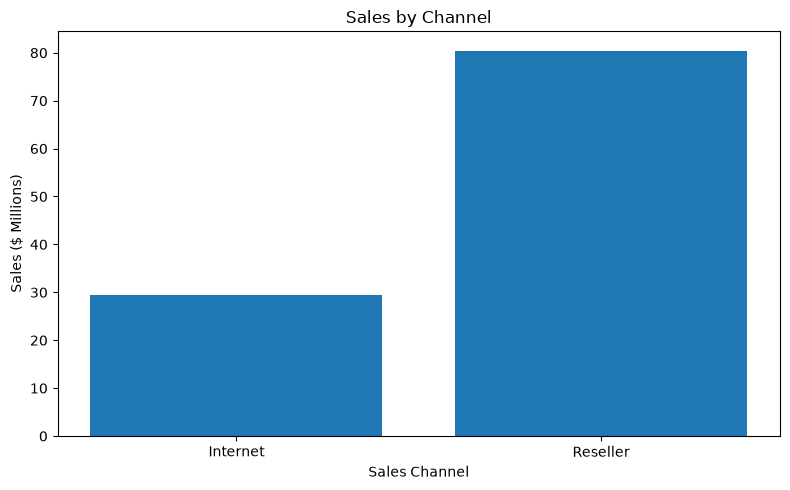

In [104]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.bar(
    channel_eda["Channel"],
    channel_eda["Sales"] / 1_000_000
)

plt.title("Sales by Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Sales ($ Millions)")

plt.tight_layout()
plt.show()

## EDA 2 — Monthly Sales Trend

In [105]:
internet_eda = clean_fact_internet_sales.copy()
reseller_eda = clean_fact_reseller_sales.copy()

internet_eda["OrderDate"] = pd.to_datetime(
    internet_eda["OrderDate"],
    errors="coerce"
)

reseller_eda["OrderDate"] = pd.to_datetime(
    reseller_eda["OrderDate"],
    errors="coerce"
)

print("Internet invalid dates:",
      internet_eda["OrderDate"].isna().sum())

print("Reseller invalid dates:",
      reseller_eda["OrderDate"].isna().sum())

Internet invalid dates: 0
Reseller invalid dates: 0


In [106]:
#  Create Monthly sales data
internet_monthly = (
    internet_eda
    .groupby(internet_eda["OrderDate"].dt.to_period("M"))["SalesAmount"]
    .sum()
    .reset_index()
)

internet_monthly.columns = ["Month", "InternetSales"]

reseller_monthly = (
    reseller_eda
    .groupby(reseller_eda["OrderDate"].dt.to_period("M"))["SalesAmount"]
    .sum()
    .reset_index()
)

reseller_monthly.columns = ["Month", "ResellerSales"]

In [108]:
# Combining 
monthly_sales = pd.merge(
    internet_monthly,
    reseller_monthly,
    on="Month",
    how="outer"
).fillna(0)

monthly_sales["TotalSales"] = (
    monthly_sales["InternetSales"]
    + monthly_sales["ResellerSales"]
)

monthly_sales = monthly_sales.sort_values("Month")

display(monthly_sales.head())

,Month,InternetSales,ResellerSales,TotalSales
0,2010-12,43421.0364,4.893286e+05,5.327496e+05
1,2011-01,469823.9148,1.538408e+06,2.008232e+06
2,2011-02,466334.9030,0.000000e+00,4.663349e+05
3,2011-03,485198.6594,2.010618e+06,2.495817e+06
4,2011-04,502073.8458,0.000000e+00,5.020738e+05


In [109]:
print("Number of months:", len(monthly_sales))

print(
    "First month:",
    monthly_sales["Month"].min()
)

print(
    "Last month:",
    monthly_sales["Month"].max()
)

print(
    "Total Internet Sales:",
    monthly_sales["InternetSales"].sum()
)

print(
    "Total Reseller Sales:",
    monthly_sales["ResellerSales"].sum()
)

print(
    "Total Combined Sales:",
    monthly_sales["TotalSales"].sum()
)

Number of months: 38
First month: 2010-12
Last month: 2014-01
Total Internet Sales: 29358677.220699996
Total Reseller Sales: 80450596.98230001
Total Combined Sales: 109809274.20300001


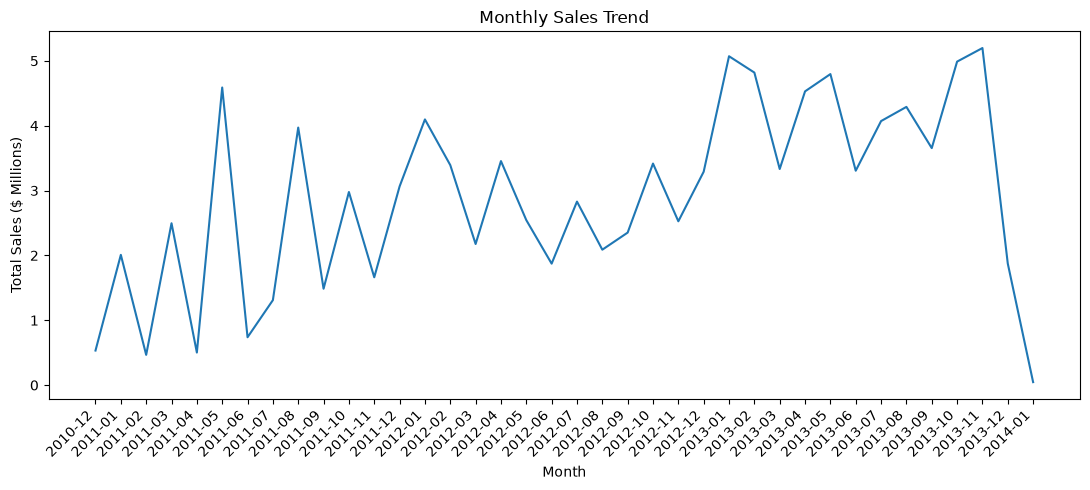

In [110]:
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_sales["Month"].astype(str),
    monthly_sales["TotalSales"] / 1_000_000
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales ($ Millions)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [112]:
# Highest and Lowest Month 
highest_month = monthly_sales.loc[
    monthly_sales["TotalSales"].idxmax()
]

lowest_month = monthly_sales.loc[
    monthly_sales["TotalSales"].idxmin()
]

print("Highest Sales Month")
print("-" * 30)
print("Month:", highest_month["Month"])
print("Sales:", highest_month["TotalSales"])

print("\nLowest Sales Month")
print("-" * 30)
print("Month:", lowest_month["Month"])
print("Sales:", lowest_month["TotalSales"])

Highest Sales Month
------------------------------
Month: 2013-11
Sales: 5197154.914

Lowest Sales Month
------------------------------
Month: 2014-01
Sales: 45694.72


In [113]:
# Month Trends
monthly_sales["Year"] = monthly_sales["Month"].dt.year

yearly_sales = (
    monthly_sales
    .groupby("Year")["TotalSales"]
    .sum()
    .reset_index()
)

yearly_sales["TotalSales"] = (
    yearly_sales["TotalSales"]
)

display(yearly_sales)

,Year,TotalSales
0,2010,5.327496e+05
1,2011,2.526833e+07
2,2012,3.403612e+07
3,2013,4.992638e+07
4,2014,4.569472e+04


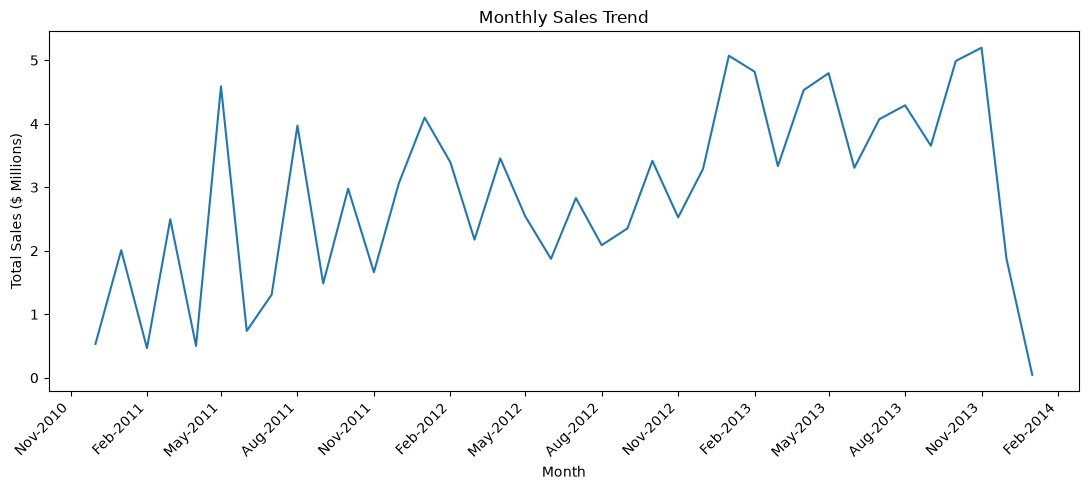

In [114]:
import matplotlib.dates as mdates

monthly_chart = monthly_sales.copy()

monthly_chart["MonthDate"] = monthly_chart["Month"].dt.to_timestamp()

plt.figure(figsize=(11, 5))

plt.plot(
    monthly_chart["MonthDate"],
    monthly_chart["TotalSales"] / 1_000_000
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales ($ Millions)")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Product Category Performance

In [115]:
display(
    clean_dim_product[
        ["ProductKey", "Category"]
    ].head()
)

,ProductKey,Category
0,226,Clothing
1,227,Clothing
2,228,Clothing
3,229,Clothing
4,230,Clothing


In [116]:
internet_product_eda = clean_fact_internet_sales.merge(
    clean_dim_product[["ProductKey", "Category"]],
    on="ProductKey",
    how="left"
)

print("Internet rows:", len(internet_product_eda))
print(
    "Missing Category after join:",
    internet_product_eda["Category"].isna().sum()
)

Internet rows: 60398
Missing Category after join: 0


In [118]:
internet_category = (
    internet_product_eda
    .groupby("Category")["SalesAmount"]
    .sum()
    .reset_index()
)

internet_category.columns = [
    "Category",
    "InternetSales"
]

reseller_category = (
    reseller_product_eda
    .groupby("Category")["SalesAmount"]
    .sum()
    .reset_index()
)

reseller_category.columns = [
    "Category",
    "ResellerSales"
]

In [119]:
category_eda = pd.merge(
    internet_category,
    reseller_category,
    on="Category",
    how="outer"
).fillna(0)

category_eda["TotalSales"] = (
    category_eda["InternetSales"]
    + category_eda["ResellerSales"]
)

category_eda = category_eda.sort_values(
    "TotalSales",
    ascending=False
).reset_index(drop=True)

display(category_eda)

,Category,InternetSales,ResellerSales,TotalSales
0,Bikes,2.831814e+07,6.630238e+07,9.462053e+07
1,Components,0.000000e+00,1.179908e+07,1.179908e+07
2,Clothing,3.397726e+05,1.777841e+06,2.117613e+06
3,Accessories,7.007600e+05,5.712979e+05,1.272058e+06


In [120]:
print("Category Internet Sales:",
      category_eda["InternetSales"].sum())

print("Original Internet Sales:",
      internet_sales)

print()

print("Category Reseller Sales:",
      category_eda["ResellerSales"].sum())

print("Original Reseller Sales:",
      reseller_sales)

Category Internet Sales: 29358677.2207
Original Internet Sales: 29358677.220699992

Category Reseller Sales: 80450596.9823
Original Reseller Sales: 80450596.98230001


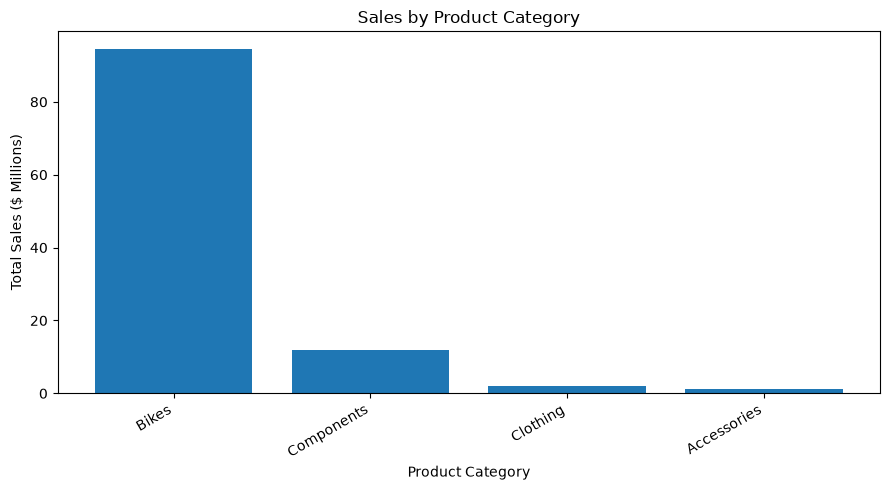

In [121]:
plt.figure(figsize=(9, 5))

plt.bar(
    category_eda["Category"],
    category_eda["TotalSales"] / 1_000_000
)

plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales ($ Millions)")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [122]:
top_category = category_eda.iloc[0]

print("Top Category")
print("-" * 30)
print("Category:", top_category["Category"])
print("Sales:", top_category["TotalSales"])

Top Category
------------------------------
Category: Bikes
Sales: 94620526.2077


In [123]:
bottom_category = category_eda.iloc[-1]

print("\nLowest Category")
print("-" * 30)
print("Category:", bottom_category["Category"])
print("Sales:", bottom_category["TotalSales"])


Lowest Category
------------------------------
Category: Accessories
Sales: 1272057.8878


In [124]:
category_eda["SalesSharePct"] = (
    category_eda["TotalSales"]
    / category_eda["TotalSales"].sum()
    * 100
)

display(category_eda)

,Category,InternetSales,ResellerSales,TotalSales,SalesSharePct
0,Bikes,2.831814e+07,6.630238e+07,9.462053e+07,86.168064
1,Components,0.000000e+00,1.179908e+07,1.179908e+07,10.745064
2,Clothing,3.397726e+05,1.777841e+06,2.117613e+06,1.928447
3,Accessories,7.007600e+05,5.712979e+05,1.272058e+06,1.158425


In [126]:
cleaned_datasets = {
    "DimCustomer": clean_dim_customer,
    "DimEmployee": clean_dim_employee,
    "DimGeography": clean_dim_geography,
    "DimProduct": clean_dim_product,
    "DimReseller": clean_dim_reseller,
    "DimSalesTerritory": clean_dim_sales_territory,
    "FactInternetSales": clean_fact_internet_sales,
    "FactResellerSales": clean_fact_reseller_sales
}

for name, df in cleaned_datasets.items():
    file_path = os.path.join(
        output_folder,
        f"{name}_Clean.csv"
    )
    
    df.to_csv(
        file_path,
        index=False
    )
    
    print(f"{name}: {df.shape} → {file_path}")

DimCustomer: (18484, 13) → cleaned_data\DimCustomer_Clean.csv
DimEmployee: (21, 9) → cleaned_data\DimEmployee_Clean.csv
DimGeography: (655, 6) → cleaned_data\DimGeography_Clean.csv
DimProduct: (397, 7) → cleaned_data\DimProduct_Clean.csv
DimReseller: (701, 4) → cleaned_data\DimReseller_Clean.csv
DimSalesTerritory: (11, 4) → cleaned_data\DimSalesTerritory_Clean.csv
FactInternetSales: (60398, 13) → cleaned_data\FactInternetSales_Clean.csv
FactResellerSales: (60855, 14) → cleaned_data\FactResellerSales_Clean.csv


In [127]:
print("\nExported files:")
print("-" * 50)

for file in os.listdir(output_folder):
    print(file)


Exported files:
--------------------------------------------------
DimCustomer_Clean.csv
DimEmployee_Clean.csv
DimGeography_Clean.csv
DimProduct_Clean.csv
DimReseller_Clean.csv
DimSalesTerritory_Clean.csv
FactInternetSales_Clean.csv
FactResellerSales_Clean.csv


In [128]:
print("FINAL CLEAN DATA VALIDATION")
print("=" * 60)

for name, df in cleaned_datasets.items():
    
    file_path = os.path.join(
        output_folder,
        f"{name}_Clean.csv"
    )
    
    exported_df = pd.read_csv(file_path)
    
    print(
        f"{name:<22} "
        f"Original Clean: {df.shape} | "
        f"Exported: {exported_df.shape}"
    )

FINAL CLEAN DATA VALIDATION
DimCustomer            Original Clean: (18484, 13) | Exported: (18484, 13)
DimEmployee            Original Clean: (21, 9) | Exported: (21, 9)
DimGeography           Original Clean: (655, 6) | Exported: (655, 6)
DimProduct             Original Clean: (397, 7) | Exported: (397, 7)
DimReseller            Original Clean: (701, 4) | Exported: (701, 4)
DimSalesTerritory      Original Clean: (11, 4) | Exported: (11, 4)
FactInternetSales      Original Clean: (60398, 13) | Exported: (60398, 13)
FactResellerSales      Original Clean: (60855, 14) | Exported: (60855, 14)
